# L'arbre de décision, de l'indice de Gini au scoring de crédit

Un organisme de crédit doit décider, dossier par dossier, s'il accorde un prêt. La contrainte n'est pas seulement d'être précis : la décision doit pouvoir être **expliquée** au client refusé et **justifiée** devant un régulateur. C'est exactement ce que produit un arbre de décision — une suite de questions oui/non que l'on peut lire à voix haute.

Ce notebook construit un arbre de décision **entièrement à la main**, en numpy, à partir des formules qui le définissent : l'indice de Gini, l'entropie de Shannon, et la règle de choix d'un point de coupure. On vérifie ensuite que cette implémentation reproduit exactement celle de scikit-learn, puis on l'applique à un portefeuille de crédit pour mesurer ce qu'elle vaut et où elle échoue.

**Pourquoi réimplémenter un algorithme qui existe déjà en librairie ?** Parce que l'arbre de décision n'est pas un modèle parmi d'autres : c'est le composant élémentaire de Random Forest, de Gradient Boosting et de XGBoost. Chacun de leurs hyperparamètres — `max_depth`, `min_child_weight`, `gamma`, `colsample` — se lit directement sur le mécanisme construit ici. Le coder une fois évite de les régler à l'aveugle ensuite.

**Public visé.** Vous programmez un peu en Python et vous connaissez les bases des statistiques. Aucune connaissance préalable des arbres de décision n'est supposée.

**Prérequis techniques.** numpy, pandas, matplotlib, scikit-learn. Rien d'autre à installer.

**Plan**

1. Le portefeuille de crédit
2. Le mécanisme sur six clients, calculé à la main
3. L'implémentation from scratch
4. Validation contre scikit-learn
5. Application au portefeuille
6. Effet des hyperparamètres
7. Ce que la démo établit
8. Pour aller plus loin

**Reproductibilité.** Toutes les graines aléatoires sont fixées à 42. Les versions utilisées sont affichées à la première cellule.

## 1. Le portefeuille de crédit

On travaille sur un portefeuille de 2 000 dossiers de prêt, généré de façon reproductible pour que ce notebook s'exécute sans télécharger de fichier. Le mécanisme de génération est volontairement **non linéaire** : le risque de défaut y dépend d'interactions entre variables (par exemple, beaucoup de retards *et* un fort taux d'endettement), ce qu'un arbre sait capter et qu'une régression linéaire manquerait sans terme d'interaction explicite.

Cinq variables décrivent chaque dossier, et une sixième indique l'issue observée.

In [1]:
import sys
from dataclasses import dataclass
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             precision_score, recall_score, classification_report)

GRAINE = 42
pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 12)

print(f"Python       {sys.version.split()[0]}")
print(f"numpy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"graine fixee a {GRAINE}")

Python       3.11.15
numpy        2.4.4
pandas       3.0.2
scikit-learn 1.8.0
graine fixee a 42


In [2]:
def generer_portefeuille(n_dossiers=2000, graine=GRAINE):
    """Construit un portefeuille de credit synthetique mais realiste.

    Le risque de defaut depend de facon non lineaire des variables :
    deux interactions sont injectees volontairement (retards x endettement,
    et faible revenu x endettement), ce qu'un arbre doit savoir retrouver.

    Retourne un DataFrame de n_dossiers lignes et 6 colonnes.
    """
    rng = np.random.default_rng(graine)

    revenu = np.clip(np.round(rng.gamma(6.0, 6.5, n_dossiers) + 12, 1), 12, 160)
    retards = np.clip(rng.poisson(1.1, n_dossiers), 0, 9)
    anciennete = np.clip(rng.gamma(2.0, 28, n_dossiers).round(0), 0, 300)
    montant = np.round(revenu * rng.uniform(0.4, 3.2, n_dossiers), 1)
    endettement = np.clip(
        np.round(montant / (revenu * rng.uniform(2.5, 6.0, n_dossiers)) * 100, 1), 3, 95)

    # Score de risque latent : effets principaux puis deux interactions
    score = (-3.1
             + 0.85 * retards
             + 0.045 * endettement
             - 0.030 * revenu
             - 0.006 * anciennete
             + 0.55 * ((retards >= 3) & (endettement > 45))     # interaction 1
             + 0.90 * ((revenu < 25) & (endettement > 40)))     # interaction 2

    proba_defaut = 1 / (1 + np.exp(-score))                     # sigmoide
    defaut = (rng.uniform(size=n_dossiers) < proba_defaut).astype(int)

    return pd.DataFrame({
        "revenu_annuel_keur": revenu,          # revenu annuel net, en milliers d'euros
        "retards_12m": retards,                # nb de retards de paiement sur 12 mois
        "anciennete_emploi_mois": anciennete,  # anciennete dans l'emploi actuel, en mois
        "montant_pret_keur": montant,          # montant demande, en milliers d'euros
        "taux_endettement_pct": endettement,   # charge de credit / revenu, en %
        "defaut": defaut,                      # 1 = defaut constate, 0 = pret rembourse
    })


portefeuille = generer_portefeuille()
FEATURES = [c for c in portefeuille.columns if c != "defaut"]

print(f"Dossiers          : {portefeuille.shape[0]}")
print(f"Variables         : {len(FEATURES)}")
print(f"Taux de defaut    : {portefeuille['defaut'].mean():.1%}")
print()
print(portefeuille.head())

Dossiers          : 2000
Variables         : 5
Taux de defaut    : 18.2%

   revenu_annuel_keur  retards_12m  anciennete_emploi_mois  montant_pret_keur  taux_endettement_pct  defaut
0                53.8            2                    88.0               34.7                  23.7       0
1                61.7            1                    52.0              109.2                  60.4       0
2                50.8            0                    59.0               33.5                  16.5       0
3                48.6            1                    54.0               89.6                  34.1       0
4                64.2            2                     9.0              156.2                  65.8       0


Un taux de défaut de 18 % : les classes sont déséquilibrées, sans l'être au point de rendre l'exercice pathologique. Ce point resurgira à la section 5, quand il faudra choisir un seuil de décision.

Un détail qui distingue les arbres de la plupart des autres modèles : **aucune standardisation n'est nécessaire ici**. Un arbre ne compare jamais deux variables entre elles, il compare une variable à un seuil. Multiplier une colonne par 1 000 laisserait l'arbre strictement identique — ce qui n'est le cas ni d'un SVM, ni d'une régression régularisée.

## 2. Le mécanisme sur six clients, calculé à la main

Avant d'écrire quoi que ce soit de général, on réduit le problème à six dossiers et deux variables. À cette taille, chaque nombre produit par l'algorithme peut être vérifié au crayon.

### L'impureté : mesurer le désordre d'un groupe

Un groupe de clients est **pur** si tous ont connu la même issue : la prédiction y est certaine. Il est impur si les deux issues s'y mélangent. Deux mesures quantifient cela.

L'**indice de Gini** vaut `1 − Σ pₖ²`, où `pₖ` est la proportion de la classe `k` dans le groupe. Ce n'est pas une convention arbitraire : c'est la probabilité de se tromper si l'on étiquetait un client au hasard, en tirant l'étiquette selon les proportions observées dans son groupe. Un groupe pur donne 0, un groupe parfaitement mélangé donne 0,5 en binaire.

L'**entropie** vaut `− Σ pₖ log₂(pₖ)`, et se mesure en bits. Elle répond à une autre question : combien de questions oui/non faudrait-il encore poser, en moyenne, pour connaître l'issue d'un client du groupe ? Un groupe pur donne 0 bit, un groupe à 50/50 donne exactement 1 bit.

In [3]:
def gini(y):
    """Indice de Gini : 1 - somme(p_k^2). Vaut 0 pour un groupe pur."""
    if y.size == 0:
        return 0.0
    _, effectifs = np.unique(y, return_counts=True)
    p = effectifs / y.size
    return float(1.0 - np.sum(p ** 2))


def entropie(y):
    """Entropie de Shannon : -somme(p_k * log2(p_k)), en bits."""
    if y.size == 0:
        return 0.0
    _, effectifs = np.unique(y, return_counts=True)
    p = effectifs / y.size
    return float(-np.sum(p * np.log2(p)))     # np.unique exclut les classes absentes


# Six dossiers, deux variables : revenu annuel (k EUR) et retards sur 12 mois
X6 = np.array([[40, 5],
               [30, 4],
               [35, 2],
               [20, 1],
               [45, 1],
               [25, 0]], dtype=float)
y6 = np.array([1, 1, 0, 1, 0, 0])              # 1 = defaut
NOMS6 = ["revenu", "retards"]
CLIENTS = ["A", "B", "C", "D", "E", "F"]

print(pd.DataFrame(X6, columns=NOMS6, index=CLIENTS).assign(defaut=y6))
print()
print(f"Gini du groupe complet     : {gini(y6):.4f}   (3 defauts / 3 sains)")
print(f"Entropie du groupe complet : {entropie(y6):.4f}   soit 1 bit d'incertitude")
print()
print(f"Gini d'un groupe pur       : {gini(np.array([0, 0, 0, 0])):.4f}")
print(f"Gini d'un groupe 50/50     : {gini(np.array([0, 0, 1, 1])):.4f}")

   revenu  retards  defaut
A    40.0      5.0       1
B    30.0      4.0       1
C    35.0      2.0       0
D    20.0      1.0       1
E    45.0      1.0       0
F    25.0      0.0       0

Gini du groupe complet     : 0.5000   (3 defauts / 3 sains)
Entropie du groupe complet : 1.0000   soit 1 bit d'incertitude

Gini d'un groupe pur       : 0.0000
Gini d'un groupe 50/50     : 0.5000


### Combien de coupures faut-il tester ?

Une variable continue comme le revenu peut prendre une infinité de valeurs, donc en apparence une infinité de seuils. En réalité, un seuil ne sert qu'à séparer les clients en deux groupes : deux seuils qui produisent la même séparation sont le même seuil. Il suffit donc de placer un candidat **entre chaque paire de valeurs distinctes consécutives**. Avec `u` valeurs distinctes, cela fait `u − 1` candidats, et pas un de plus.

Par convention on prend le point milieu, ce qui maximise la marge entre les deux groupes. C'est pour cette raison qu'un arbre produit des seuils comme 22,5 alors qu'aucun client n'affiche ce revenu.

In [4]:
def seuils_candidats(colonne):
    """Points milieux entre valeurs distinctes consecutives.

    u valeurs distinctes -> u-1 seuils. Toute autre valeur produirait
    une separation deja couverte par l'un de ces candidats.
    """
    valeurs = np.unique(colonne)              # np.unique trie et dedoublonne
    if valeurs.size < 2:
        return np.empty(0)
    return (valeurs[:-1] + valeurs[1:]) / 2.0


for j, nom in enumerate(NOMS6):
    seuils = seuils_candidats(X6[:, j])
    print(f"{nom:8s} valeurs {np.unique(X6[:, j])} -> {seuils.size} seuils {seuils}")

revenu   valeurs [20. 25. 30. 35. 40. 45.] -> 5 seuils [22.5 27.5 32.5 37.5 42.5]
retards  valeurs [0. 1. 2. 4. 5.] -> 4 seuils [0.5 1.5 3.  4.5]


### Choisir la meilleure coupure

Une coupure produit deux groupes. Pour juger de sa qualité, on compare l'impureté du groupe de départ à l'impureté **moyenne** des deux groupes obtenus — moyenne pondérée par leurs effectifs :

```
gain = impureté(parent) − [ (n_gauche/n) · impureté(gauche) + (n_droite/n) · impureté(droite) ]
```

La pondération n'est pas cosmétique, elle est indispensable. Sans elle, isoler un seul client dans un groupe pur ferait chuter la moyenne simple des deux impuretés et semblerait résoudre le problème, alors que 99 % des clients seraient restés aussi mélangés qu'avant. La pondération est ce qui empêche l'algorithme d'obtenir un bon score en ne réglant rien.

In [5]:
def impurete_ponderee(X, y, feature, seuil, mesure=gini):
    """Impurete moyenne des deux groupes, ponderee par leurs effectifs."""
    gauche = X[:, feature] <= seuil
    droite = ~gauche
    return (gauche.mean() * mesure(y[gauche])
            + droite.mean() * mesure(y[droite]))


lignes = []
for j, nom in enumerate(NOMS6):
    for seuil in seuils_candidats(X6[:, j]):
        lignes.append({
            "coupure": f"{nom} <= {seuil}",
            "gini_pondere": round(impurete_ponderee(X6, y6, j, seuil, gini), 4),
            "gain_gini": round(gini(y6) - impurete_ponderee(X6, y6, j, seuil, gini), 4),
            "gain_information": round(
                entropie(y6) - impurete_ponderee(X6, y6, j, seuil, entropie), 4),
        })

tableau = pd.DataFrame(lignes)
print(tableau.to_string(index=False))
print()
meilleure = tableau.loc[tableau["gain_gini"].idxmax()]
print(f"Meilleure coupure : {meilleure['coupure']} "
      f"(gain de Gini = {meilleure['gain_gini']})")

       coupure  gini_pondere  gain_gini  gain_information
revenu <= 22.5        0.4000     0.1000            0.1909
revenu <= 27.5        0.5000     0.0000            0.0000
revenu <= 32.5        0.4444     0.0556            0.0817
revenu <= 37.5        0.5000     0.0000            0.0000
revenu <= 42.5        0.4000     0.1000            0.1909
retards <= 0.5        0.4000     0.1000            0.1909
retards <= 1.5        0.4444     0.0556            0.0817
retards <= 3.0        0.2500     0.2500            0.4591
retards <= 4.5        0.4000     0.1000            0.1909

Meilleure coupure : retards <= 3.0 (gain de Gini = 0.25)


Trois choses se lisent dans ce tableau.

**Gini et entropie désignent la même gagnante**, et produisent même le classement complet dans le même ordre. C'est le cas général. La différence entre les deux mesures est un coût de calcul : le Gini n'utilise que des multiplications, l'entropie exige un logarithme par classe et par nœud. Sur des millions de coupures évaluées, cela finit par compter — d'où le Gini par défaut dans scikit-learn.

**Deux coupures ont un gain rigoureusement nul.** Elles séparent le groupe en deux moitiés aussi mélangées que le groupe de départ : elles n'apprennent rien.

**L'algorithme retient les retards, pas le revenu.** Personne ne le lui a dit. Il a comparé neuf nombres et retrouvé, sur ces six dossiers, la règle qu'un analyste crédit formulerait par expérience : au-delà de trois retards, le revenu ne rattrape plus rien.

En reprenant le groupe des clients à trois retards ou moins, une seconde coupure sur le revenu à 22,5 k€ sépare parfaitement les deux issues restantes. L'arbre s'arrête là, avec deux règles et six dossiers correctement classés. C'est cette procédure — chercher la meilleure coupure, séparer, recommencer sur chaque moitié — que la section suivante généralise.

## 3. L'implémentation from scratch

L'algorithme qui construit les arbres s'appelle **CART** (*Classification And Regression Trees*). Il tient en trois règles :

1. au nœud courant, évaluer toutes les variables et tous les seuils candidats ;
2. retenir la coupure qui réduit le plus l'impureté ;
3. recommencer sur chacun des deux groupes obtenus, jusqu'à une condition d'arrêt.

CART est **glouton** : il retient la meilleure coupure immédiate sans se demander si une coupure moins bonne maintenant ouvrirait un meilleur arbre deux niveaux plus bas. Ce n'est pas un raccourci d'implémentation mais une nécessité. Avec 100 observations, 10 variables et une profondeur de 4, le nombre d'arbres possibles dépasse 10⁴⁴ — chercher le meilleur arbre est un problème NP-complet. CART évalue moins de 15 000 coupures là où l'exploration exhaustive en demanderait 10⁴⁴.

La conséquence à retenir : **l'arbre produit est un optimum local, jamais global.** Il reste donc de la performance inexploitée, et c'est précisément ce que les méthodes d'ensemble vont récupérer en combinant plusieurs arbres imparfaits plutôt qu'en cherchant l'arbre parfait.

On commence par la structure de données : un nœud porte soit une question, soit une prédiction.

In [6]:
@dataclass
class Noeud:
    """Un noeud de l'arbre : soit une question, soit une prediction.

    feature / seuil : la question posee (None pour une feuille)
    gauche / droite : les deux sous-arbres (None pour une feuille)
    prediction      : la classe predite (None pour un noeud interne)
    proba           : proportion de defauts dans le noeud
    n               : nombre d'observations tombant dans ce noeud
    impurete        : impurete du noeud, dans la mesure choisie
    """
    feature: Optional[int] = None
    seuil: Optional[float] = None
    gauche: Optional["Noeud"] = None
    droite: Optional["Noeud"] = None
    prediction: Optional[int] = None
    proba: Optional[float] = None
    n: int = 0
    impurete: float = 0.0

    def est_feuille(self):
        return self.prediction is not None

La classe qui suit contient tout l'algorithme. Elle n'importe aucune librairie de machine learning : uniquement numpy, et les deux fonctions d'impureté écrites à la section 2.

Quatre garde-fous sont exposés, ceux que l'on retrouve dans toutes les implémentations : `max_depth` (profondeur maximale), `min_samples_split` (effectif minimal pour tenter une coupure), `min_samples_leaf` (effectif minimal d'un groupe résultant) et `min_impurity_decrease` (gain minimal exigé). Leur rôle est mesuré à la section 6.

In [7]:
class ArbreDecision:
    """Arbre de decision binaire (CART) pour la classification.

    Parametres
    ----------
    max_depth : int ou None
        Profondeur maximale. None = pas de limite.
    min_samples_split : int
        Effectif minimal d'un noeud pour tenter une coupure.
    min_samples_leaf : int
        Effectif minimal de chacun des deux groupes issus d'une coupure.
    min_impurity_decrease : float
        Reduction d'impurete minimale, ponderee par la taille du noeud,
        exigee pour valider une coupure.
    criterion : {"gini", "entropy"}
        Mesure d'impurete utilisee.
    """

    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1,
                 min_impurity_decrease=0.0, criterion="gini"):
        self.max_depth = np.inf if max_depth is None else max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.min_impurity_decrease = min_impurity_decrease
        self.mesure = gini if criterion == "gini" else entropie
        self.racine = None
        self.n_total = 0

    # ---------- construction ----------

    def _creer_feuille(self, y):
        """Une feuille predit la classe majoritaire de son groupe."""
        classes, effectifs = np.unique(y, return_counts=True)
        return Noeud(prediction=int(classes[np.argmax(effectifs)]),
                     proba=float(np.mean(y == 1)),
                     n=int(y.size),
                     impurete=self.mesure(y))

    def _meilleure_coupure(self, X, y):
        """Balaie toutes les variables et tous les seuils candidats.

        Retourne (feature, seuil, reduction d'impurete), ou (None, None, 0.0)
        si aucune coupure admissible n'ameliore l'impurete.
        """
        impurete_parent = self.mesure(y)
        meilleure = (None, None, 0.0)

        for j in range(X.shape[1]):
            colonne = X[:, j]
            for seuil in seuils_candidats(colonne):
                gauche = colonne <= seuil
                n_g, n_d = int(gauche.sum()), int((~gauche).sum())
                if n_g < self.min_samples_leaf or n_d < self.min_samples_leaf:
                    continue
                # moyenne ponderee par les effectifs (cf. section 2)
                pondere = ((n_g / y.size) * self.mesure(y[gauche])
                           + (n_d / y.size) * self.mesure(y[~gauche]))
                reduction = impurete_parent - pondere
                # 1e-12 : marge numerique, les egalites vont au premier trouve
                if reduction > meilleure[2] + 1e-12:
                    meilleure = (j, float(seuil), float(reduction))

        return meilleure

    def _construire(self, X, y, profondeur):
        """Recursion principale : couper, puis recommencer sur chaque moitie."""
        impurete = self.mesure(y)

        arret = (impurete == 0.0                          # groupe deja pur
                 or profondeur >= self.max_depth
                 or y.size < self.min_samples_split
                 or y.size < 2 * self.min_samples_leaf)
        if arret:
            return self._creer_feuille(y)

        feature, seuil, reduction = self._meilleure_coupure(X, y)

        # le gain est pondere par la part du noeud dans l'echantillon total,
        # comme le fait scikit-learn pour min_impurity_decrease
        if feature is None or reduction * (y.size / self.n_total) <= self.min_impurity_decrease:
            return self._creer_feuille(y)

        gauche = X[:, feature] <= seuil
        noeud = Noeud(feature=feature, seuil=seuil, n=int(y.size), impurete=impurete)
        noeud.gauche = self._construire(X[gauche], y[gauche], profondeur + 1)
        noeud.droite = self._construire(X[~gauche], y[~gauche], profondeur + 1)
        return noeud

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y).astype(int)
        self.n_total = y.size
        self.racine = self._construire(X, y, profondeur=0)
        return self

    # ---------- prediction ----------

    def _descendre(self, x, noeud):
        """Suit les questions de la racine jusqu'a une feuille."""
        while not noeud.est_feuille():
            noeud = noeud.gauche if x[noeud.feature] <= noeud.seuil else noeud.droite
        return noeud

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._descendre(x, self.racine).prediction for x in X])

    def predict_proba(self, X):
        """Proportion de defauts dans la feuille atteinte par chaque observation."""
        X = np.asarray(X, dtype=float)
        return np.array([self._descendre(x, self.racine).proba for x in X])

    # ---------- inspection ----------

    def n_feuilles(self, noeud=None):
        noeud = noeud if noeud is not None else self.racine
        if noeud.est_feuille():
            return 1
        return self.n_feuilles(noeud.gauche) + self.n_feuilles(noeud.droite)

    def profondeur_atteinte(self, noeud=None, d=0):
        noeud = noeud if noeud is not None else self.racine
        if noeud.est_feuille():
            return d
        return max(self.profondeur_atteinte(noeud.gauche, d + 1),
                   self.profondeur_atteinte(noeud.droite, d + 1))

    def regles(self, noms, noeud=None, prefixe=""):
        """Rend l'arbre sous forme de lignes lisibles."""
        noeud = noeud if noeud is not None else self.racine
        if noeud.est_feuille():
            issue = "DEFAUT" if noeud.prediction == 1 else "sain"
            return [f"{prefixe}=> {issue}  (n={noeud.n}, p(defaut)={noeud.proba:.2f})"]
        titre = f"{prefixe}[{noms[noeud.feature]} <= {noeud.seuil:.2f}]  (n={noeud.n})"
        return ([titre]
                + self.regles(noms, noeud.gauche, prefixe + "   oui ")
                + self.regles(noms, noeud.droite, prefixe + "   non "))

On la vérifie d'abord sur les six clients de la section 2, dont on connaît la réponse attendue : une coupure sur les retards à 3, puis une coupure sur le revenu à 22,5.

In [8]:
arbre_6 = ArbreDecision().fit(X6, y6)

print("\n".join(arbre_6.regles(NOMS6)))
print()
print(f"Feuilles              : {arbre_6.n_feuilles()}")
print(f"Profondeur            : {arbre_6.profondeur_atteinte()}")
print(f"Exactitude sur X6     : {(arbre_6.predict(X6) == y6).mean():.3f}")

[retards <= 3.00]  (n=6)
   oui [revenu <= 22.50]  (n=4)
   oui    oui => DEFAUT  (n=1, p(defaut)=1.00)
   oui    non => sain  (n=3, p(defaut)=0.00)
   non => DEFAUT  (n=2, p(defaut)=1.00)

Feuilles              : 3
Profondeur            : 2
Exactitude sur X6     : 1.000


Les deux coupures attendues, dans l'ordre attendu, et six dossiers sur six correctement classés.

Ce 100 % mérite d'être regardé de près, parce qu'il n'a aucune valeur. Laissé sans contrainte, un arbre atteint **toujours** une exactitude parfaite en entraînement : tant qu'un groupe contient deux observations de classes différentes, il existe forcément une variable sur laquelle elles diffèrent, donc une coupure qui les sépare. La récursion ne s'arrête que sur des groupes purs — au pire des groupes d'une seule observation. L'erreur d'entraînement nulle est une propriété de construction, pas une performance.

Autrement dit, un arbre non contraint mémorise. La section 6 mesure précisément le prix de cette mémorisation.

## 4. Validation contre scikit-learn

Une implémentation qui donne les bons résultats sur six lignes n'est pas encore validée. On la confronte à `DecisionTreeClassifier`, avec les mêmes réglages, sur le portefeuille complet — et on compare les prédictions **une par une**, pas seulement les scores agrégés. Deux modèles peuvent afficher la même exactitude en se trompant sur des dossiers différents.

In [9]:
X = portefeuille[FEATURES].to_numpy()
y = portefeuille["defaut"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=GRAINE, stratify=y)

print(f"Entrainement : {X_train.shape[0]} dossiers")
print(f"Test         : {X_test.shape[0]} dossiers")
print()
print(f"{'profondeur':>11}{'feuilles (nous)':>17}{'feuilles (sklearn)':>20}"
      f"{'accord':>9}")

for profondeur in [2, 3, 4, 5]:
    nous = ArbreDecision(max_depth=profondeur, min_samples_leaf=25).fit(X_train, y_train)
    eux = DecisionTreeClassifier(max_depth=profondeur, min_samples_leaf=25,
                                 random_state=GRAINE).fit(X_train, y_train)
    accord = (nous.predict(X_test) == eux.predict(X_test)).mean()
    print(f"{profondeur:>11}{nous.n_feuilles():>17}{eux.get_n_leaves():>20}"
          f"{accord:>9.3f}")

Entrainement : 1500 dossiers
Test         : 500 dossiers

 profondeur  feuilles (nous)  feuilles (sklearn)   accord
          2                4                   4    1.000
          3                8                   8    1.000
          4               13                  13    1.000
          5               19                  19    1.000


Accord parfait sur les 500 dossiers de test, à toutes les profondeurs testées, et même nombre de feuilles. L'implémentation from scratch **est** l'algorithme de scikit-learn, aux optimisations de vitesse près : scikit-learn est écrit en Cython et trie les colonnes une fois pour toutes, là où la version ci-dessus rebalaie chaque candidat en Python pur.

Cette égalité n'est pas garantie en général. Elle tient ici parce qu'aucune égalité stricte n'apparaît entre deux coupures concurrentes : quand deux coupures affichent exactement le même gain, l'ordre de parcours départage, et il n'a pas de raison d'être le même dans les deux implémentations. C'est aussi ce qui rend un arbre sensible à de très petites variations des données — un point sur lequel on revient à la section 7.

La suite utilise `DecisionTreeClassifier` pour les balayages d'hyperparamètres, où seule la vitesse compte : on vient d'établir que les deux implémentations décrivent le même modèle.

## 5. Application au portefeuille

On entraîne maintenant un arbre lisible — profondeur 4, feuilles d'au moins 25 dossiers — et on mesure ce qu'il vaut sur les dossiers qu'il n'a jamais vus.

Deux métriques sont utilisées. L'**exactitude** (part de bonnes réponses) est trompeuse ici : prédire « aucun défaut » pour tout le monde en donne déjà 82 %, puisque 18 % seulement des dossiers font défaut. On lui adjoint l'**AUC**, l'aire sous la courbe ROC, qui mesure la capacité du modèle à **classer** les dossiers du plus risqué au moins risqué. Une AUC de 0,5 correspond au hasard, 1,0 à un classement parfait.

In [10]:
arbre = ArbreDecision(max_depth=4, min_samples_leaf=25).fit(X_train, y_train)

proba_test = arbre.predict_proba(X_test)
pred_test = arbre.predict(X_test)

taux_base = y_test.mean()
print(f"Taux de defaut sur le test        : {taux_base:.1%}")
print(f"Exactitude du modele              : {(pred_test == y_test).mean():.3f}")
print(f"Exactitude en predisant 'sain'    : {1 - taux_base:.3f}   <- reference a battre")
print(f"AUC                               : {roc_auc_score(y_test, proba_test):.3f}")
print()
print(classification_report(y_test, pred_test,
                            target_names=["sain", "defaut"], digits=3))

Taux de defaut sur le test        : 18.2%
Exactitude du modele              : 0.846
Exactitude en predisant 'sain'    : 0.818   <- reference a battre
AUC                               : 0.791

              precision    recall  f1-score   support

        sain      0.861     0.968     0.911       409
      defaut      0.675     0.297     0.412        91

    accuracy                          0.846       500
   macro avg      0.768     0.632     0.662       500
weighted avg      0.827     0.846     0.821       500



L'exactitude de 0,846 dépasse à peine la référence naïve de 0,818 : prise seule, elle donnerait l'impression d'un modèle inutile. L'AUC de 0,79 raconte l'inverse — le modèle classe correctement les dossiers par risque dans 79 % des paires (un défaut, un sain) qu'on lui soumet. C'est le classement qui intéresse un service crédit, pas l'étiquette binaire.

La question suivante est celle du seuil. Par défaut, on refuse un dossier quand sa probabilité de défaut dépasse 0,5. Ce seuil n'a aucune justification métier : il suppose qu'un défaut accordé coûte autant qu'un bon client refusé, ce qui est faux dans les deux sens selon l'établissement.

In [11]:
lignes = []
for seuil in [0.50, 0.40, 0.30, 0.25, 0.15]:
    refus = (proba_test > seuil).astype(int)
    lignes.append({
        "seuil": seuil,
        "dossiers_refuses": int(refus.sum()),
        "precision": round(precision_score(y_test, refus, zero_division=0), 3),
        "rappel": round(recall_score(y_test, refus), 3),
        "defauts_evites": int(((refus == 1) & (y_test == 1)).sum()),
        "bons_clients_perdus": int(((refus == 1) & (y_test == 0)).sum()),
    })

print(pd.DataFrame(lignes).to_string(index=False))

 seuil  dossiers_refuses  precision  rappel  defauts_evites  bons_clients_perdus
  0.50                40      0.675   0.297              27                   13
  0.40                59      0.593   0.385              35                   24
  0.30               105      0.495   0.571              52                   53
  0.25               156      0.417   0.714              65                   91
  0.15               180      0.383   0.758              69                  111


Le tableau chiffre l'arbitrage. Au seuil par défaut, on refuse 40 dossiers et on évite 27 défauts sur les 91 du portefeuille — soit 30 % du risque, au prix de 13 bons clients refusés. En descendant à 0,25, on évite 65 défauts (71 % du risque) mais on refuse 91 bons clients.

Aucun de ces seuils n'est « le bon » : le choix dépend du coût d'un défaut rapporté à la marge d'un prêt sain, et cette information ne se trouve pas dans les données. **Le modèle produit un classement ; le seuil est une décision de gestion.** Confondre les deux est l'erreur la plus fréquente sur ce type de projet.

Reste l'atout propre à l'arbre : ses règles se lisent.

In [12]:
print("\n".join(arbre.regles(FEATURES)))

[taux_endettement_pct <= 64.70]  (n=1500)
   oui [retards_12m <= 2.50]  (n=1224)
   oui    oui [taux_endettement_pct <= 37.75]  (n=1108)
   oui    oui    oui [anciennete_emploi_mois <= 25.50]  (n=580)
   oui    oui    oui    oui => sain  (n=146, p(defaut)=0.12)
   oui    oui    oui    non => sain  (n=434, p(defaut)=0.04)
   oui    oui    non [retards_12m <= 1.50]  (n=528)
   oui    oui    non    oui => sain  (n=414, p(defaut)=0.11)
   oui    oui    non    non => sain  (n=114, p(defaut)=0.25)
   oui    non [taux_endettement_pct <= 34.85]  (n=116)
   oui    non    oui [taux_endettement_pct <= 20.30]  (n=60)
   oui    non    oui    oui => sain  (n=30, p(defaut)=0.07)
   oui    non    oui    non => sain  (n=30, p(defaut)=0.20)
   oui    non    non [revenu_annuel_keur <= 55.30]  (n=56)
   oui    non    non    oui => DEFAUT  (n=31, p(defaut)=0.74)
   oui    non    non    non => sain  (n=25, p(defaut)=0.44)
   non [retards_12m <= 1.50]  (n=276)
   non    oui [revenu_annuel_keur <= 34.10]  (n=

Chaque ligne se traduit en français. Le groupe le plus risqué du portefeuille — taux d'endettement supérieur à 64,7 %, plus d'un retard, revenu inférieur à 53 k€ — regroupe 48 dossiers dont 88 % ont fait défaut. À l'opposé, les dossiers peu endettés, sans retards répétés et avec plus de deux ans d'ancienneté affichent 4 % de défauts sur 434 dossiers.

Ces deux règles peuvent être présentées telles quelles à un comité de crédit, testées par un métier qui n'a jamais entendu parler de machine learning, et versées dans un dossier réglementaire. Aucune méthode d'ensemble ne rend ce service : une forêt de 500 arbres a une bien meilleure AUC, mais plus aucune règle à montrer.

On note au passage que l'arbre a retrouvé la première interaction injectée dans les données à la section 1 — le croisement entre endettement élevé et retards répétés — sans qu'on lui ait fourni le moindre terme d'interaction. C'est la propriété qui rend les arbres si efficaces sur des données tabulaires hétérogènes.

## 6. Effet des hyperparamètres

Deux paramètres suffisent à contrôler l'essentiel du comportement d'un arbre. On les fait varier et on mesure l'écart entre entraînement et test — l'écart **est** le sur-apprentissage.

In [13]:
def courbe(parametre, valeurs):
    """Entraine un arbre par valeur du parametre et retourne les AUC train/test."""
    resultats = []
    for v in valeurs:
        modele = DecisionTreeClassifier(random_state=GRAINE, **{parametre: v})
        modele.fit(X_train, y_train)
        resultats.append({
            parametre: v if v is not None else "aucune",
            "feuilles": modele.get_n_leaves(),
            "auc_train": round(roc_auc_score(y_train, modele.predict_proba(X_train)[:, 1]), 3),
            "auc_test": round(roc_auc_score(y_test, modele.predict_proba(X_test)[:, 1]), 3),
        })
    return pd.DataFrame(resultats)


profondeurs = [1, 2, 3, 4, 5, 6, 8, 10, 15, None]
table_profondeur = courbe("max_depth", profondeurs)
print(table_profondeur.to_string(index=False))

max_depth  feuilles  auc_train  auc_test
        1         2      0.664     0.658
        2         4      0.726     0.723
        3         8      0.777     0.776
        4        16      0.802     0.795
        5        28      0.829     0.770
        6        44      0.862     0.733
        8        88      0.913     0.698
       10       146      0.965     0.679
       15       224      0.997     0.682
   aucune       253      1.000     0.664


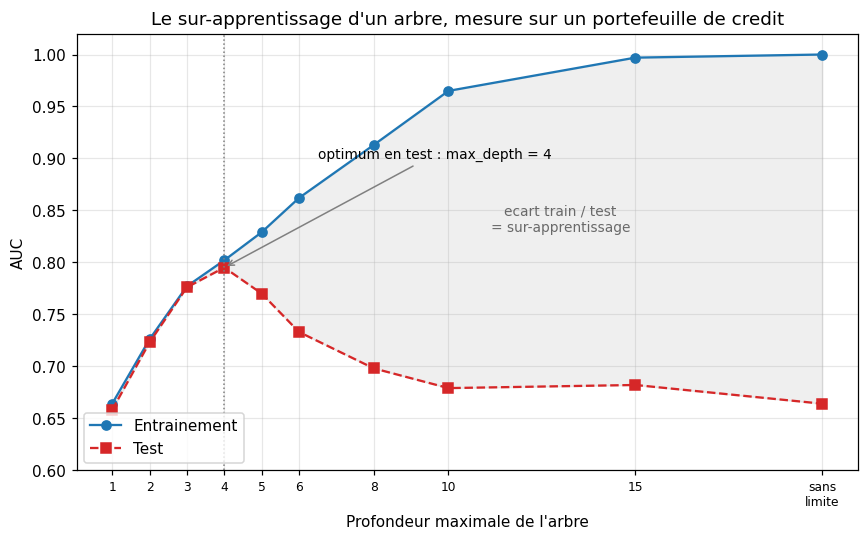

In [14]:
valeurs_x = [d if d is not None else 20 for d in profondeurs]     # None trace en 20

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(valeurs_x, table_profondeur["auc_train"], "o-",
        color="#1f77b4", label="Entrainement")
ax.plot(valeurs_x, table_profondeur["auc_test"], "s--",
        color="#d62728", label="Test")
meilleure_profondeur = valeurs_x[int(table_profondeur["auc_test"].idxmax())]
ax.axvline(meilleure_profondeur, color="grey", linewidth=1, linestyle=":")
ax.annotate(f"optimum en test : max_depth = {meilleure_profondeur}",
            xy=(meilleure_profondeur, table_profondeur["auc_test"].max()),
            xytext=(6.5, 0.90), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="grey"))
ax.fill_between(valeurs_x, table_profondeur["auc_test"], table_profondeur["auc_train"],
                color="grey", alpha=0.12)
ax.text(13, 0.83, "ecart train / test\n= sur-apprentissage",
        fontsize=9, color="dimgrey", ha="center")
ax.set_xticks(valeurs_x)
ax.set_xticklabels([str(d) if d is not None else "sans\nlimite" for d in profondeurs],
                   fontsize=8)
ax.set_xlabel("Profondeur maximale de l'arbre")
ax.set_ylabel("AUC")
ax.set_title("Le sur-apprentissage d'un arbre, mesure sur un portefeuille de credit")
ax.set_ylim(0.60, 1.02)
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La figure montre le phénomène dans sa forme la plus nette. L'AUC d'entraînement monte jusqu'à 1,000 : l'arbre finit par classer parfaitement les dossiers qu'il a vus, comme annoncé à la section 3. L'AUC de test, elle, culmine à 0,795 pour une profondeur de 4, puis **redescend** jusqu'à 0,664 — le niveau d'un arbre de profondeur 1.

Un arbre de profondeur 15 compte 224 feuilles, est illisible, et classe à peine mieux qu'un arbre à une seule question (0,682 contre 0,658). La zone grisée entre les deux courbes est le sur-apprentissage rendu visible : tout ce qui est gagné en entraînement au-delà de la profondeur 4 est de la mémorisation, et elle se paie sur les dossiers réels.

Le second paramètre attaque le problème par l'autre bout : au lieu de limiter la hauteur de l'arbre, il impose un effectif minimal aux feuilles.

In [15]:
table_feuille = courbe("min_samples_leaf", [1, 5, 10, 25, 50, 100, 200])
print(table_feuille.to_string(index=False))

 min_samples_leaf  feuilles  auc_train  auc_test
                1       253      1.000     0.664
                5       135      0.959     0.738
               10        86      0.920     0.760
               25        41      0.870     0.782
               50        23      0.832     0.795
              100        11      0.798     0.783
              200         6      0.758     0.770


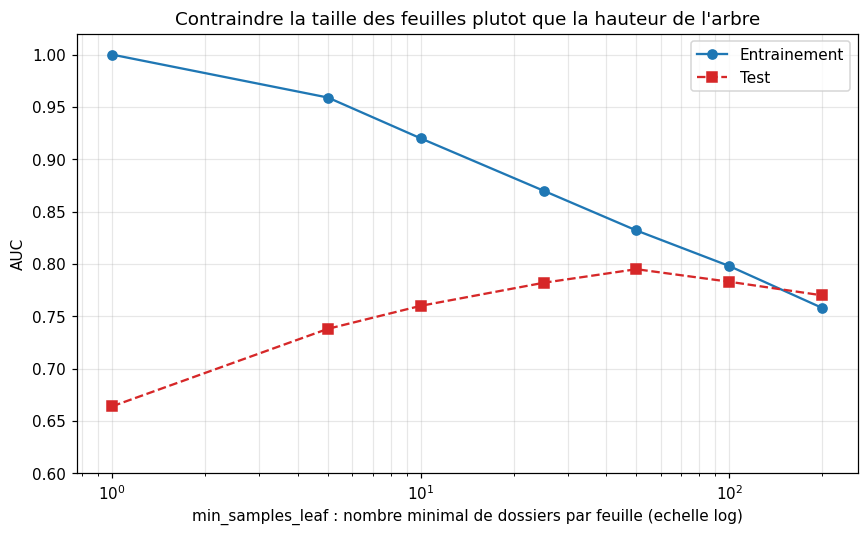

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(table_feuille["min_samples_leaf"], table_feuille["auc_train"], "o-",
        color="#1f77b4", label="Entrainement")
ax.plot(table_feuille["min_samples_leaf"], table_feuille["auc_test"], "s--",
        color="#d62728", label="Test")
ax.set_xscale("log")
ax.set_xlabel("min_samples_leaf : nombre minimal de dossiers par feuille (echelle log)")
ax.set_ylabel("AUC")
ax.set_title("Contraindre la taille des feuilles plutot que la hauteur de l'arbre")
ax.set_ylim(0.60, 1.02)
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

Même conclusion par un autre chemin. À `min_samples_leaf = 1`, chaque feuille peut ne contenir qu'un seul dossier : l'AUC d'entraînement vaut 1,000 et l'AUC de test s'effondre à 0,664. En exigeant 50 dossiers par feuille, l'AUC de test remonte à 0,795 — la même valeur que l'optimum obtenu avec `max_depth`.

**Les règles pratiques qui en découlent :**

- `max_depth` est le paramètre à régler en premier. C'est celui qui a le plus d'effet, et le seul dont la valeur se traduise directement en nombre de questions posées.
- `min_samples_leaf` est le garde-fou complémentaire, et le plus robuste sur données bruitées : il empêche qu'une règle repose sur trois dossiers.
- Ces deux paramètres ne s'ajoutent pas : au-delà d'un certain point ils contraignent la même chose. Les régler ensemble par validation croisée est plus sûr que de les empiler à l'intuition.
- Une feuille contenant moins d'une trentaine de dossiers ne devrait pas être présentée comme une règle métier, quelle que soit sa pureté apparente.

## 7. Ce que la démo établit

- **Un arbre est entièrement descriptible par trois formules.** L'indice de Gini, la moyenne pondérée des impuretés, et la règle de choix du meilleur gain suffisent à reproduire, en 120 lignes de numpy, un modèle dont les prédictions coïncident à 100 % avec celles de scikit-learn sur 500 dossiers de test.

- **L'erreur d'entraînement nulle est une propriété de construction, pas une performance.** Un arbre non contraint atteint systématiquement 100 % en entraînement, parce que la récursion ne s'arrête que sur des groupes purs. Sur le portefeuille, cet arbre parfait affiche 0,664 d'AUC en test, contre 0,795 pour un arbre de profondeur 4.

- **Le réglage anti-sur-apprentissage se joue sur deux leviers équivalents.** Limiter la profondeur ou imposer un effectif minimal par feuille conduit ici au même optimum (0,795 d'AUC). Le second est préférable sur données bruitées, parce qu'il contraint ce qui compte vraiment : le nombre de dossiers derrière chaque règle.

- **L'exactitude est une mauvaise métrique sur classes déséquilibrées.** Avec 18 % de défauts, prédire « sain » pour tout le monde donne déjà 0,818. L'AUC, qui mesure le classement, distingue un modèle utile d'un modèle inerte — et le seuil de décision reste un arbitrage de gestion, pas un résultat du modèle.

- **La limite principale de l'arbre seul est son instabilité.** Le choix de la coupure racine conditionne tout ce qui suit, et il se joue parfois entre deux candidats aux gains quasi identiques. Modifier quelques dossiers d'entraînement peut donc produire un arbre entièrement différent. C'est ce défaut précis que les méthodes d'ensemble exploitent : le bagging moyenne des arbres profonds pour annuler cette variance, le boosting enchaîne des arbres peu profonds pour réduire le biais. Les deux partent du même constat et le résolvent en sens inverse.

- **Ce que cette démo ne montre pas.** Les données sont synthétiques et sans valeurs manquantes ; un portefeuille réel exigerait un traitement des variables catégorielles, un contrôle de la stabilité temporelle, et une validation croisée plutôt qu'une simple séparation entraînement/test. Le modèle obtenu est un point de départ interprétable, pas un modèle de production.

## 8. Pour aller plus loin

- **Breiman, Friedman, Olshen & Stone, *Classification and Regression Trees* (Wadsworth, 1984).** Le livre qui introduit CART, l'indice de Gini comme critère de coupure et l'élagage par coût-complexité. Toutes les formules implémentées ici en viennent.

- **Hastie, Tibshirani & Friedman, *The Elements of Statistical Learning*, chapitre 9.2.** Traitement moderne et compact des méthodes à base d'arbres, avec la dérivation du critère d'élagage. Le PDF est mis à disposition gratuitement par les auteurs sur le site de Stanford.

- **Documentation scikit-learn, section *Decision Trees*.** La sous-section « Mathematical formulation » donne les formules exactes de l'implémentation, utiles pour confronter ses propres calculs à ceux de la librairie.

- **Shannon, *A Mathematical Theory of Communication* (Bell System Technical Journal, 1948).** L'article fondateur d'où vient l'entropie utilisée comme critère alternatif au Gini.

- **Documentation scikit-learn, exemple *Post pruning decision trees with cost complexity pruning*.** Prolongement direct de la section 6 : l'élagage a posteriori, troisième levier de contrôle du sur-apprentissage, et l'ancêtre du paramètre `gamma` de XGBoost.